In [ ]:
# ==============================================================================
# 1 IMPORT LIBRARIES & GPU SETUP
# ==============================================================================
import os
import warnings
import logging

# Turn off warning C++ dan TensorFlow sebelum inisialisasi
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')
import absl.logging
absl.logging.set_verbosity(absl.logging.FATAL)

import gc
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf

tf.get_logger().setLevel(logging.FATAL)
tf.autograph.set_verbosity(3)

# Konfigurasi Global Path (Environment Lokal)
DATASET_PATH = r"C:\Users\DELL\OneDrive\Documents\TA\Dedicated GPU test laptop\Dataset"
WORKING_PATH = r"C:\Users\DELL\OneDrive\Documents\TA\Dedicated GPU test laptop\Output"

if not os.path.exists(WORKING_PATH):
    os.makedirs(WORKING_PATH)

print("=" * 80)
print("SETUP KOMPUTASI (LOCAL RTX 3080) & LINGKUNGAN BERSIH")
print("=" * 80)

# Setup Single Dedicated GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
            
        strategy = tf.distribute.OneDeviceStrategy(device="/gpu:0")
        print(f"[INFO] Mendeteksi {len(gpus)} GPU. Memory growth diaktifkan.")
        print(f"[INFO] Strategi Distribusi Aktif: Single GPU (Local).")
    except RuntimeError as e:
        print(f"[ERROR] Inisialisasi GPU gagal: {e}")
else:
    print("[WARNING] GPU tidak terdeteksi. Berjalan di CPU.")

SETUP KOMPUTASI (LOCAL RTX 3080) & LINGKUNGAN BERSIH
[INFO] Mendeteksi 1 GPU. Memory growth diaktifkan.
[INFO] Strategi Distribusi Aktif: Single GPU (Local).


In [2]:
# ==============================================================================
# 2.1 LOAD DATASET
# ==============================================================================
print("[INFO] Mencari file dataset di direktori lokal...")

file_paths = {}

for dirname, _, filenames in os.walk(DATASET_PATH):
    for filename in filenames:
        if filename.endswith('.csv'):
            fname_lower = filename.lower()
            if 'liver' in fname_lower:
                file_paths['Liver'] = os.path.join(dirname, filename)
            elif 'prostate' in fname_lower:
                file_paths['Prostate'] = os.path.join(dirname, filename)
            elif 'thyroid' in fname_lower:
                file_paths['Thyroid'] = os.path.join(dirname, filename)
            elif 'lung' in fname_lower:
                file_paths['Lung'] = os.path.join(dirname, filename)

if len(file_paths) < 4:
    raise FileNotFoundError(f"[ERROR] Dataset tidak lengkap di path: {DATASET_PATH}")
else:
    print("[INFO] Semua file berhasil dipetakan:")
    for key, path in file_paths.items():
        print(f"       - {key}: {path}")

print("\n[INFO] Memuat dataset CSV ke memori...")

df_liver = pd.read_csv(file_paths['Liver'])
df_prostate = pd.read_csv(file_paths['Prostate'])
df_thyroid = pd.read_csv(file_paths['Thyroid'])
df_lung = pd.read_csv(file_paths['Lung'])

print("\n" + "=" * 80)
print("INFORMASI DIMENSI DATASET")
print("=" * 80)
print(f"[DATA] Liver RNA    : {df_liver.shape[0]:,} sampel | {df_liver.shape[1]-1:,} fitur")
print(f"[DATA] Prostate RNA : {df_prostate.shape[0]:,} sampel | {df_prostate.shape[1]-1:,} fitur")
print(f"[DATA] Thyroid RNA  : {df_thyroid.shape[0]:,} sampel | {df_thyroid.shape[1]-1:,} fitur")
print(f"[DATA] Lung RNA     : {df_lung.shape[0]:,} sampel | {df_lung.shape[1]-1:,} fitur")

gc.collect()

[INFO] Mencari file dataset di direktori lokal...
[INFO] Semua file berhasil dipetakan:
       - Liver: C:\Users\DELL\OneDrive\Documents\TA\Dedicated GPU test laptop\Dataset\Liver RNA Data.csv
       - Lung: C:\Users\DELL\OneDrive\Documents\TA\Dedicated GPU test laptop\Dataset\Lung RNA Data.csv
       - Prostate: C:\Users\DELL\OneDrive\Documents\TA\Dedicated GPU test laptop\Dataset\Prostate RNA Data.csv
       - Thyroid: C:\Users\DELL\OneDrive\Documents\TA\Dedicated GPU test laptop\Dataset\Thyroid RNA Data.csv

[INFO] Memuat dataset CSV ke memori...

INFORMASI DIMENSI DATASET
[DATA] Liver RNA    : 422 sampel | 20,530 fitur
[DATA] Prostate RNA : 550 sampel | 20,530 fitur
[DATA] Thyroid RNA  : 572 sampel | 20,530 fitur
[DATA] Lung RNA     : 1,099 sampel | 20,530 fitur


0

In [3]:
# 2.2 PREVIEW DATASET
print("\n" + "=" * 80)
print("[INFO] Menampilkan 5 baris pertama dari representasi tiap dataset:")
print("=" * 80)
print("Liver RNA Data:")
display(df_liver.head())
print("Prostate RNA Data")
display(df_prostate.head())
print("Thyroid RNA  Data")
display(df_thyroid.head())
print("Lung RNA  Data")
display(df_lung.head())


print("\n" + "=" * 80)
print("[INFO] Menampilkan struktur 5 kolom pertama dan 5 kolom terakhir:")
print("=" * 80)
# Menampilkan cuplikan nama fitur (gen)
print("Liver RNA Data")
display(df_liver.iloc[:, np.r_[0:5, -5:0]].head())
print("Prostate RNA Data")
display(df_prostate.iloc[:, np.r_[0:5, -5:0]].head())
print("Thyroid RNA  Data")
display(df_thyroid.iloc[:, np.r_[0:5, -5:0]].head())
print("Lung RNA  Data")
display(df_lung.iloc[:, np.r_[0:5, -5:0]].head())


[INFO] Menampilkan 5 baris pertama dari representasi tiap dataset:
Liver RNA Data:


,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS,sample_type_id
0,11.1818,5.2482,4.1956,11.5047,9.5995,9.6257,11.8053,5.6835,0.0000,8.7486,...,0.8379,6.1672,1.7494,8.0444,12.3759,8.0357,13.5037,8.7327,10.4145,1.0
1,11.0186,5.3847,0.0000,11.6690,11.3980,10.8249,11.5487,3.5408,1.4714,7.9144,...,3.5408,5.5302,0.0000,7.5066,10.5302,7.3741,13.0045,7.0466,10.3411,0.0
2,11.2430,4.0013,0.0000,12.0791,9.8248,10.5608,12.1228,3.5582,0.0000,7.9795,...,2.1586,3.1834,0.0000,8.8500,9.5592,8.5064,12.9815,2.9873,10.9926,1.0
3,11.1612,2.9374,0.0000,12.5931,9.9459,10.5179,12.5044,1.7444,0.0000,10.3039,...,0.8347,3.5813,0.4770,8.6376,10.3457,8.3303,13.5581,4.5197,13.2960,1.0
4,12.0167,4.7857,0.0000,11.4616,10.8368,10.1428,12.9470,3.8613,0.0000,9.0306,...,3.5402,3.7620,0.0000,7.9929,11.4056,8.1968,13.8179,7.2957,11.0316,1.0


Prostate RNA Data


,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS,sample_type_id
0,9.3554,5.1517,0.0000,12.4656,11.1274,10.5783,12.6987,4.5629,0.0000,5.4558,...,1.7582,3.6227,0.0,9.1784,12.4863,6.8575,11.1839,8.0296,11.2415,1.0
1,8.8729,5.9049,0.4008,12.3538,11.5348,10.5856,12.2242,5.1002,0.4008,6.1261,...,1.1895,4.5093,0.0,8.7484,13.0699,8.0385,11.2972,9.2337,10.6480,1.0
2,8.5581,4.9716,0.7574,12.2950,11.9867,11.2172,12.3527,4.3699,0.0000,6.3596,...,0.4278,3.8542,0.0,9.3038,11.2971,6.0940,10.3648,7.6376,10.8448,1.0
3,9.2085,6.7795,0.0000,11.9701,11.3146,11.3116,12.5196,3.3596,0.0000,5.9495,...,1.1098,0.6590,0.0,8.4919,12.4049,5.4921,10.6787,7.1290,11.3611,1.0
4,9.0514,5.3511,0.0000,12.5973,11.3622,10.6387,12.4639,3.9809,0.0000,5.1578,...,0.6497,2.9683,0.0,8.5714,12.2110,5.7522,11.2507,6.4412,11.4926,1.0


Thyroid RNA  Data


...

,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,BCL6B,GSTK1,SELP,SELS,sample_type_id
0,9.3554,5.1517,0.0000,12.4656,11.1274,6.8575,11.1839,8.0296,11.2415,1.0
1,8.8729,5.9049,0.4008,12.3538,11.5348,8.0385,11.2972,9.2337,10.6480,1.0
2,8.5581,4.9716,0.7574,12.2950,11.9867,6.0940,10.3648,7.6376,10.8448,1.0
3,9.2085,6.7795,0.0000,11.9701,11.3146,5.4921,10.6787,7.1290,11.3611,1.0
4,9.0514,5.3511,0.0000,12.5973,11.3622,5.7522,11.2507,6.4412,11.4926,1.0


Thyroid RNA  Data


,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,BCL6B,GSTK1,SELP,SELS,sample_type_id
0,9.5562,4.9095,0.0000,11.8042,11.4545,8.4453,11.1329,9.1381,9.8044,1.0
1,9.7895,3.7659,0.0000,11.8934,11.2879,8.1603,10.9978,6.8815,9.7011,1.0
2,10.0760,5.4943,0.4129,11.7769,11.4789,8.5665,11.2178,7.9935,10.3296,1.0
3,9.7147,4.9882,0.5070,11.7542,11.3445,8.1645,11.8492,7.8300,10.5617,1.0
4,10.4664,4.8134,0.0000,12.1551,11.9165,8.7853,11.5980,6.6358,10.6005,1.0


Lung RNA  Data


,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,BCL6B,GSTK1,SELP,SELS,sample_type_id
0,9.6503,2.7747,0.0000,11.8183,10.2685,8.9264,10.7056,4.8805,10.5206,1.0
1,7.8310,4.7796,1.1048,12.1428,11.3324,7.0836,11.9711,4.4405,10.6536,1.0
2,8.7548,4.5313,0.0000,11.4508,11.2760,6.6833,10.3993,7.2594,10.7449,1.0
3,8.5936,2.2999,0.4402,11.9383,11.3362,5.1968,9.9947,4.3153,10.2741,1.0
4,10.5411,6.6477,0.0000,12.3611,11.2828,6.7294,11.3359,6.8621,9.5222,1.0


In [4]:
# 2.3 INFORMASI DATASET & KUALITAS DATA
import io

print("=" * 80)
print("INFORMASI DATASET (REPRESENTASI: LIVER RNA DATA)")
print("=" * 80)

print("\n1. Info Dataset:")
buf = io.StringIO()
df_liver.info(verbose=False, memory_usage='deep', buf=buf)
print(buf.getvalue())

print("2. Statistik Deskriptif (Sampel 5 Fitur Gen Pertama):")
display(df_liver.iloc[:, :5].describe())

print("\n3. Missing Values (Seluruh Kelas Kanker):")
print(f"  - Liver RNA Data   : {df_liver.isnull().sum().sum()} missing values")
print(f"  - Prostate RNA Data: {df_prostate.isnull().sum().sum()} missing values")
print(f"  - Thyroid RNA Data : {df_thyroid.isnull().sum().sum()} missing values")
print(f"  - Lung RNA Data    : {df_lung.isnull().sum().sum()} missing values")

print("\n4. Duplicate Data (Seluruh Kelas Kanker):")
print(f"  - Liver RNA Data   : {df_liver.duplicated().sum()} duplikat")
print(f"  - Prostate RNA Data: {df_prostate.duplicated().sum()} duplikat")
print(f"  - Thyroid RNA Data : {df_thyroid.duplicated().sum()} duplikat")
print(f"  - Lung RNA Data    : {df_lung.duplicated().sum()} duplikat")

INFORMASI DATASET (REPRESENTASI: LIVER RNA DATA)

1. Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 422 entries, 0 to 421
Columns: 20531 entries, ARHGEF10L to sample_type_id
dtypes: float64(20531)
memory usage: 66.1 MB

2. Statistik Deskriptif (Sampel 5 Fitur Gen Pertama):


,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11
count,422.000000,422.000000,422.000000,422.000000,422.000000
mean,11.204909,4.189542,0.855747,11.788266,10.566434
std,0.722944,1.658611,1.997299,0.338696,0.602916
min,8.704400,0.000000,0.000000,10.739900,8.286100
25%,10.749200,3.104550,0.000000,11.597900,10.169825
50%,11.269500,4.146050,0.000000,11.786800,10.671350
75%,11.687075,4.992875,0.000000,11.987275,10.980500
max,13.065900,11.421700,9.427400,13.178100,12.149600



3. Missing Values (Seluruh Kelas Kanker):
  - Liver RNA Data   : 0 missing values
  - Prostate RNA Data: 0 missing values
  - Thyroid RNA Data : 0 missing values
  - Lung RNA Data    : 0 missing values

4. Duplicate Data (Seluruh Kelas Kanker):
  - Liver RNA Data   : 0 duplikat
  - Prostate RNA Data: 0 duplikat
  - Thyroid RNA Data : 0 duplikat
  - Lung RNA Data    : 0 duplikat


[INFO] Memvisualisasikan distribusi kelas (Normal vs Kanker) pada masing-masing tipe kanker...
[INFO] Target Kolom: 'sample_type_id' (0.0 = Normal, 1.0 = Kanker)


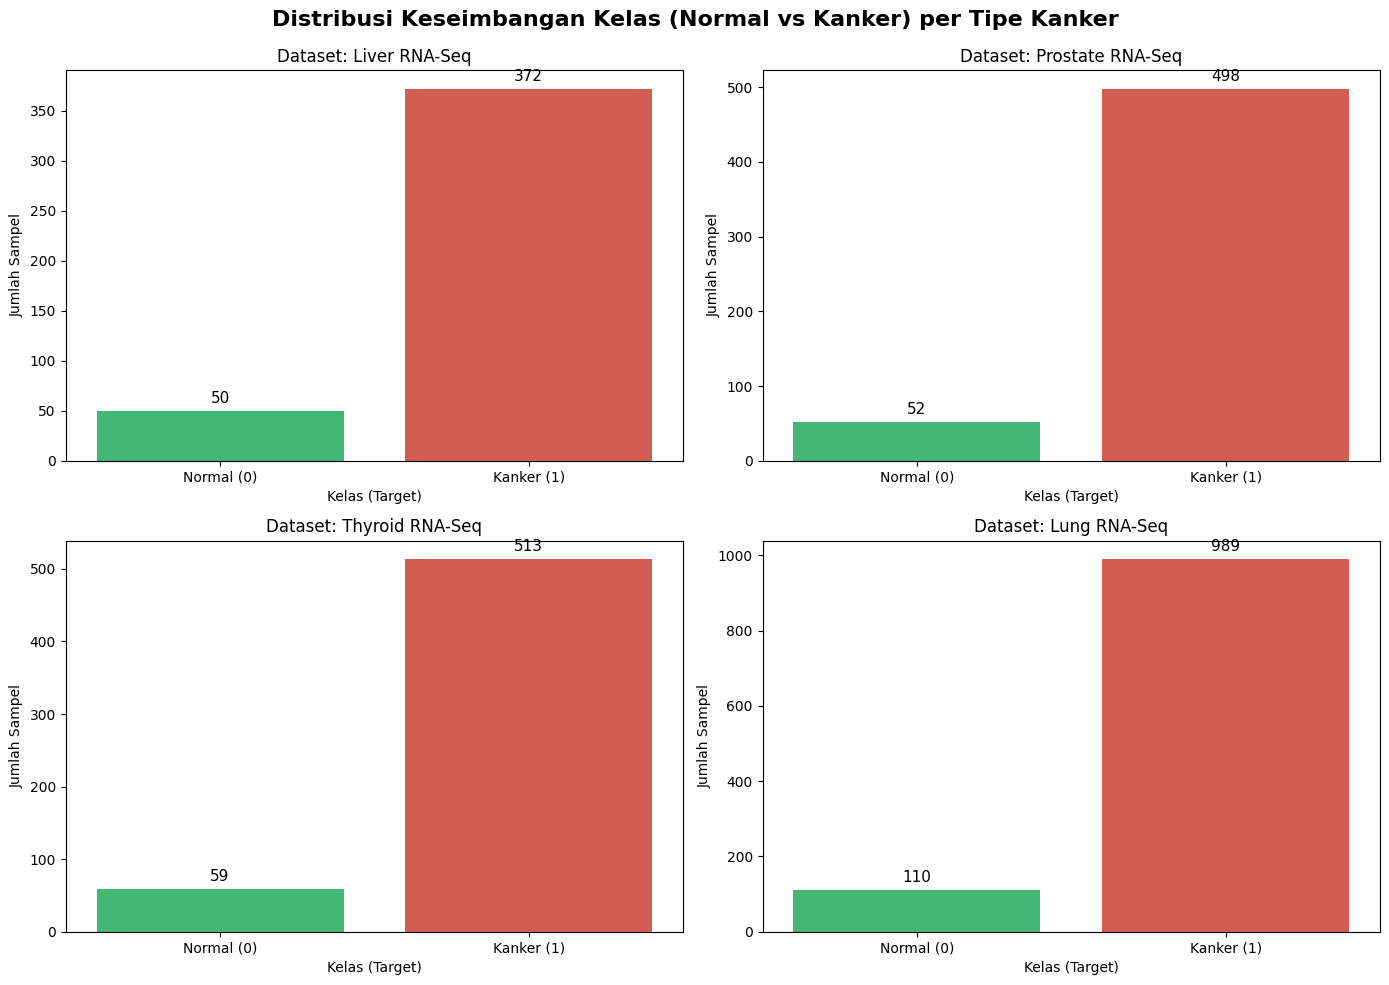


[INFO] Ringkasan Keseimbangan Data (Minoritas vs Mayoritas):
[DATA] Liver    -> Normal (0): 50    | Kanker (1): 372   | Status: TIDAK SEIMBANG (Imbalanced)
[DATA] Prostate -> Normal (0): 52    | Kanker (1): 498   | Status: TIDAK SEIMBANG (Imbalanced)
[DATA] Thyroid  -> Normal (0): 59    | Kanker (1): 513   | Status: TIDAK SEIMBANG (Imbalanced)
[DATA] Lung     -> Normal (0): 110   | Kanker (1): 989   | Status: TIDAK SEIMBANG (Imbalanced)


In [5]:
# 2.4 ANALISIS KESEIMBANGAN KELAS (NORMAL VS KANKER) PER DATASET

import matplotlib.pyplot as plt
import seaborn as sns

print("[INFO] Memvisualisasikan distribusi kelas (Normal vs Kanker) pada masing-masing tipe kanker...")
print("[INFO] Target Kolom: 'sample_type_id' (0.0 = Normal, 1.0 = Kanker)")

# Mengumpulkan dataframe ke dalam dictionary untuk kemudahan iterasi
datasets = {
    'Liver': df_liver,
    'Prostate': df_prostate,
    'Thyroid': df_thyroid,
    'Lung': df_lung
}

# Membuat kanvas (figure) untuk 4 subplot (2 baris x 2 kolom)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribusi Keseimbangan Kelas (Normal vs Kanker) per Tipe Kanker', fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, (name, df) in enumerate(datasets.items()):
    # Menghitung jumlah label pada kolom target
    counts = df['sample_type_id'].value_counts().sort_index()
    
    # Variabel untuk visualisasi
    labels = ['Normal (0)', 'Kanker (1)']
    values = [counts.get(0.0, 0), counts.get(1.0, 0)]
    
    # Membuat Bar Plot
    sns.barplot(x=labels, y=values, hue=labels, ax=axes[i], palette=['#2ecc71', '#e74c3c'], legend=False)
    
    axes[i].set_title(f'Dataset: {name} RNA-Seq')
    axes[i].set_ylabel('Jumlah Sampel')
    axes[i].set_xlabel('Kelas (Target)')
    
    # Menambahkan anotasi angka di atas setiap bar grafik
    for p in axes[i].patches:
        axes[i].annotate(format(p.get_height(), '.0f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha = 'center', va = 'center', 
                         xytext = (0, 9), 
                         textcoords = 'offset points',
                         fontsize=11)

plt.tight_layout()
fig.subplots_adjust(top=0.92) # Menyesuaikan jarak judul utama
plt.show()

# Mencetak ringkasan log analisis (Deteksi Kelas Minoritas dan Mayoritas)
print("\n[INFO] Ringkasan Keseimbangan Data (Minoritas vs Mayoritas):")
for name, df in datasets.items():
    counts = df['sample_type_id'].value_counts()
    normal_count = counts.get(0.0, 0)
    cancer_count = counts.get(1.0, 0)
    
    # Deteksi sederhana apakah dataset seimbang atau tidak
    status = "Seimbang" if abs(normal_count - cancer_count) < (0.2 * len(df)) else "TIDAK SEIMBANG (Imbalanced)"
    print(f"[DATA] {name:8s} -> Normal (0): {normal_count:<5} | Kanker (1): {cancer_count:<5} | Status: {status}")

[INFO] Mengeksplorasi distribusi nilai ekspresi gen berdasarkan kelas (Normal vs Kanker)
[INFO] Menganalisis 4 fitur gen pertama dari masing-masing dataset (Liver, Prostate, Thyroid, Lung).

ANALISIS DISTRIBUSI: LIVER RNA-SEQ


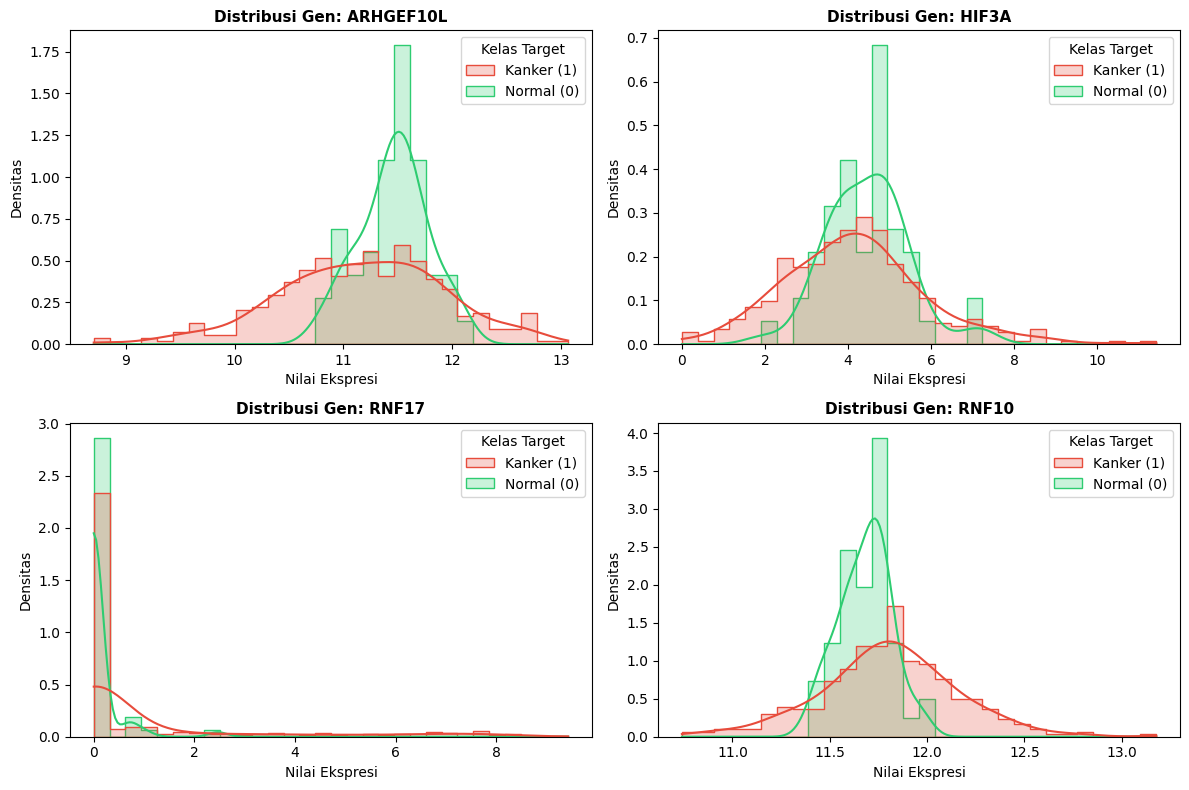

[INFO] Statistik Deskriptif Gen Sampel - Dataset Liver:


Kelas Target     Kanker (1)  Normal (0)
ARHGEF10L count  372.000000   50.000000
          mean    11.170100   11.463892
          std      0.754869    0.313779
          min      8.704400   10.772500
          25%     10.663925   11.283100
          50%     11.195000   11.488900
          75%     11.702850   11.661250
          max     13.065900   12.097400
HIF3A     count  372.000000   50.000000
          mean     4.152187    4.467462
          std      1.727309    0.978043
          min      0.000000    1.986000
          25%      2.988075    3.805900
          50%      4.083450    4.573650
          75%      5.017500    4.939950
          max     11.421700    7.175500
RNF17     count  372.000000   50.000000
          mean     0.955784    0.111474
          std      2.102548    0.402863
          min      0.000000    0.000000
          25%      0.000000    0.000000
          50%      0.000000    0.000000
          75%      0.561050    0.000000
          max      9.427400    2.465200
RNF10     count  372.000000   50.000000
          mean    11.802750   11.680498
          std      0.355046    0.133162
          min     10.739900   11.392300
          25%     11.602825   11.592325
          50%     11.808350   11.698250
          75%     12.017550   11.763700
          max     13.178100   11.973900


ANALISIS DISTRIBUSI: PROSTATE RNA-SEQ


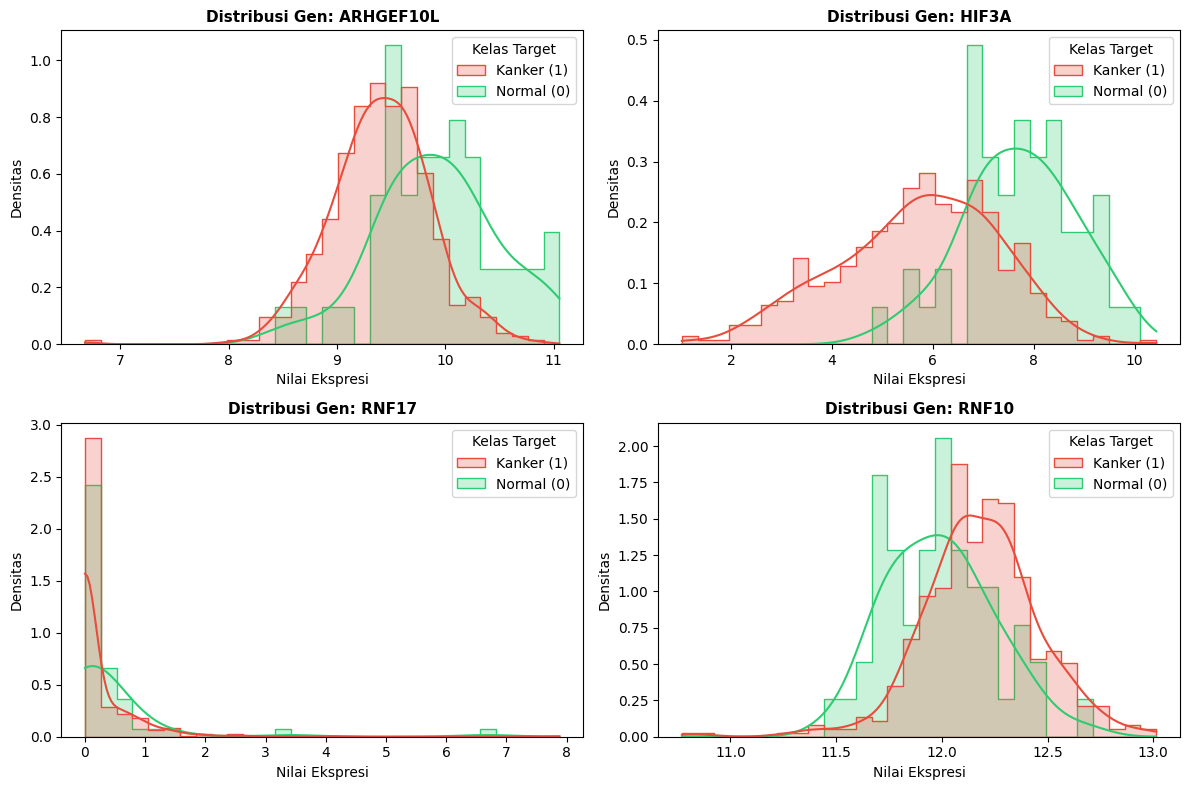

[INFO] Statistik Deskriptif Gen Sampel - Dataset Prostate:


Kelas Target     Kanker (1)  Normal (0)
ARHGEF10L count  498.000000   52.000000
          mean     9.404965    9.922569
          std      0.463048    0.567605
          min      6.672600    8.489300
          25%      9.105300    9.543700
          50%      9.409300    9.933450
          75%      9.690950   10.256975
          max     10.868900   11.053900
HIF3A     count  498.000000   52.000000
          mean     5.707890    7.713481
          std      1.572545    1.104961
          min      1.027900    4.926600
          25%      4.693825    6.922875
          50%      5.832350    7.795200
          75%      6.902425    8.447875
          max     10.428200    9.877400
RNF17     count  498.000000   52.000000
          mean     0.247226    0.402810
          std      0.671174    1.049358
          min      0.000000    0.000000
          25%      0.000000    0.000000
          50%      0.000000    0.000000
          75%      0.000000    0.490350
          max      7.881900    6.675200
RNF10     count  498.000000   52.000000
          mean    12.182968   11.990948
          std      0.277833    0.253726
          min     10.770600   11.472000
          25%     12.025525   11.803050
          50%     12.184200   11.986700
          75%     12.343150   12.133800
          max     13.014400   12.673600


ANALISIS DISTRIBUSI: THYROID RNA-SEQ


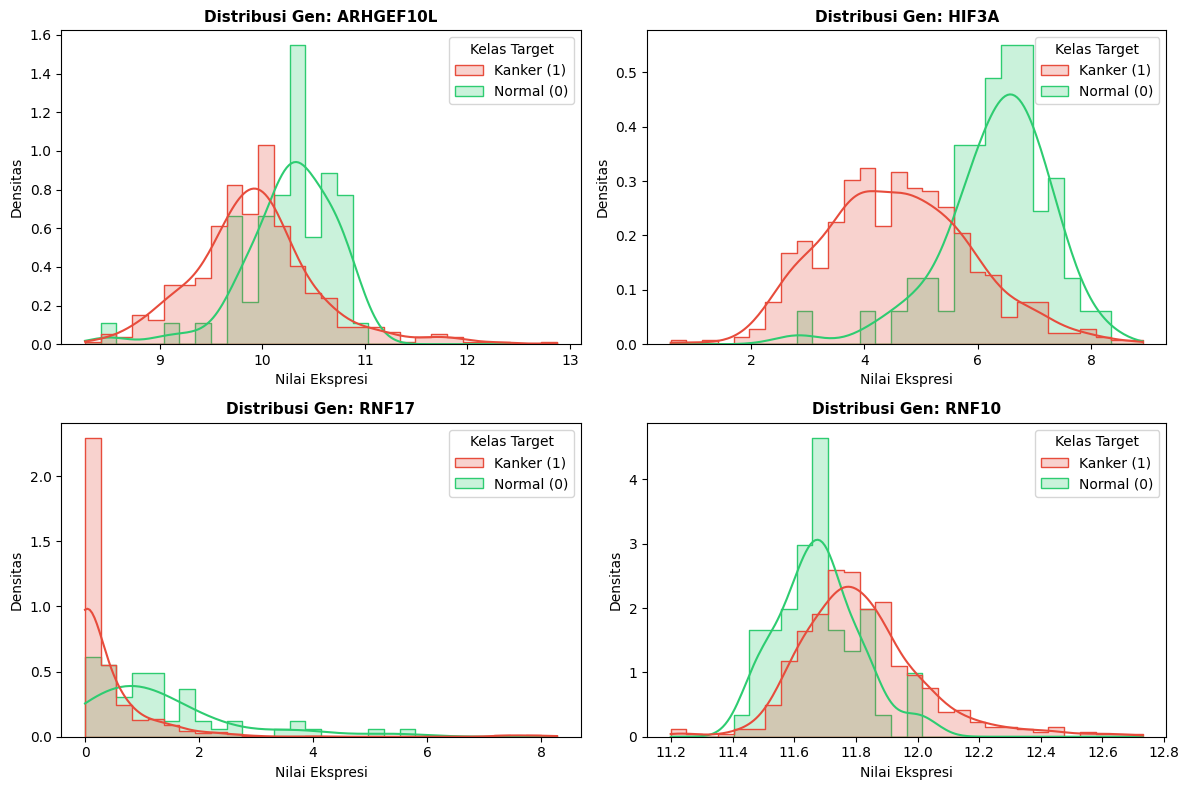

[INFO] Statistik Deskriptif Gen Sampel - Dataset Thyroid:


Kelas Target     Kanker (1)  Normal (0)
ARHGEF10L count  513.000000   59.000000
          mean     9.928173   10.272371
          std      0.619684    0.447371
          min      8.269100    8.498000
          25%      9.562400   10.082300
          50%      9.897700   10.306600
          75%     10.209900   10.594850
          max     12.873800   10.946400
HIF3A     count  513.000000   59.000000
          mean     4.594908    6.343929
          std      1.308893    0.942556
          min      0.583800    2.836800
          25%      3.683500    5.875650
          50%      4.565800    6.509300
          75%      5.481600    6.915100
          max      8.909600    8.215200
RNF17     count  513.000000   59.000000
          mean     0.408443    1.299937
          std      0.977761    1.245703
          min      0.000000    0.000000
          25%      0.000000    0.492750
          50%      0.000000    0.942300
          75%      0.480100    1.749050
          max      8.279500    5.625600
RNF10     count  513.000000   59.000000
          mean    11.817747   11.679885
          std      0.203202    0.130577
          min     11.199300   11.452500
          25%     11.684400   11.605300
          50%     11.790900   11.682800
          75%     11.908100   11.737450
          max     12.730600   12.015900


ANALISIS DISTRIBUSI: LUNG RNA-SEQ


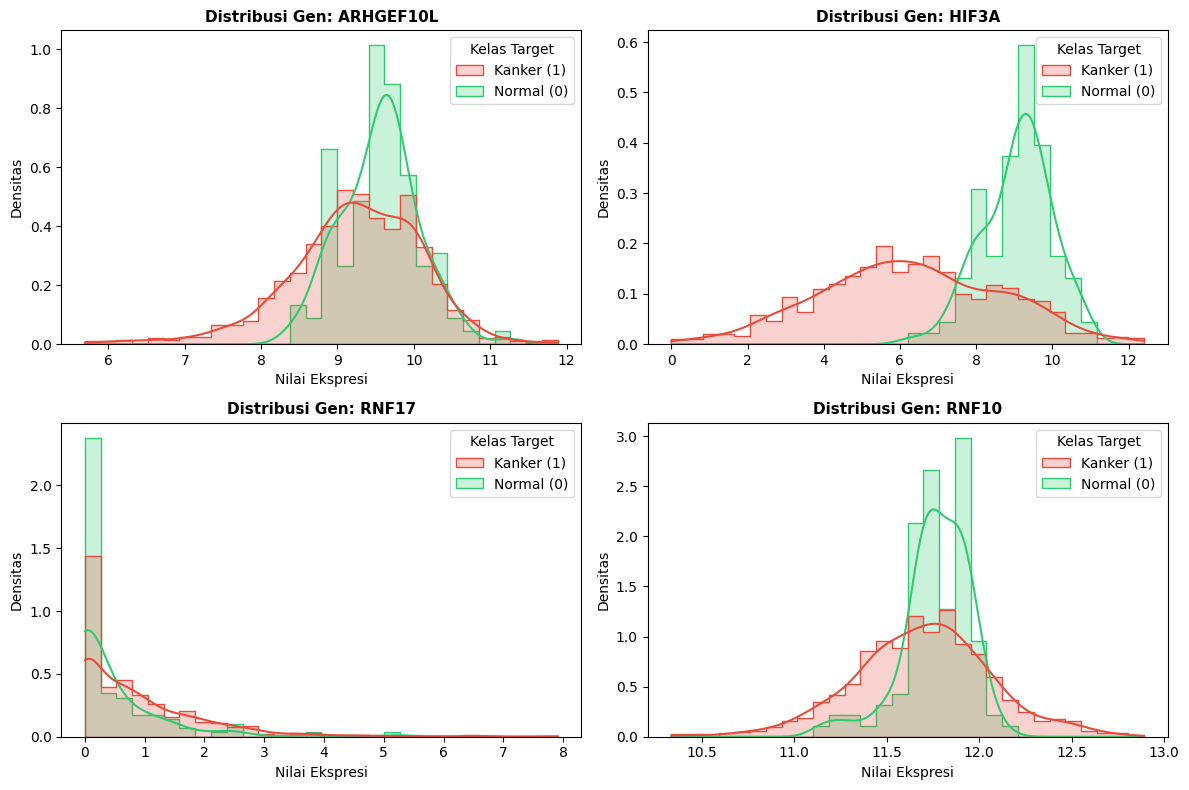

[INFO] Statistik Deskriptif Gen Sampel - Dataset Lung:


Kelas Target     Kanker (1)  Normal (0)
ARHGEF10L count  989.000000  110.000000
          mean     9.243373    9.558195
          std      0.861664    0.505706
          min      5.692200    8.419300
          25%      8.761800    9.218000
          50%      9.284800    9.587150
          75%      9.858500    9.848875
          max     11.885100   11.257100
HIF3A     count  989.000000  110.000000
          mean     6.281326    9.076529
          std      2.360320    0.910398
          min      0.000000    6.271700
          25%      4.628500    8.465375
          50%      6.231500    9.178950
          75%      8.004100    9.670750
          max     12.407100   10.858400
RNF17     count  989.000000  110.000000
          mean     0.861357    0.438702
          std      1.093931    0.824815
          min      0.000000    0.000000
          25%      0.000000    0.000000
          50%      0.547800    0.000000
          75%      1.276600    0.593050
          max      7.910300    5.240700
RNF10     count  989.000000  110.000000
          mean    11.695304   11.769056
          std      0.371218    0.180926
          min     10.334500   11.129300
          25%     11.457400   11.678575
          50%     11.701100   11.777300
          75%     11.921200   11.895600
          max     12.892800   12.132700

In [6]:
# 2.5 ANALISIS DISTRIBUSI NILAI FITUR (GENE EXPRESSION) BERDASARKAN KELAS
import matplotlib.pyplot as plt
import seaborn as sns
import gc

print("[INFO] Mengeksplorasi distribusi nilai ekspresi gen berdasarkan kelas (Normal vs Kanker)")
print("[INFO] Menganalisis 4 fitur gen pertama dari masing-masing dataset (Liver, Prostate, Thyroid, Lung).")

# Menggunakan dictionary dataset yang sudah didefinisikan sebelumnya
datasets = {
    'Liver': df_liver,
    'Prostate': df_prostate,
    'Thyroid': df_thyroid,
    'Lung': df_lung
}

for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(f"ANALISIS DISTRIBUSI: {name.upper()} RNA-SEQ")
    print("=" * 60)
    
    # Mengambil 4 fitur gen pertama (kolom indeks 0 sampai 3)
    sample_genes = df.columns[0:4]
    
    # Membuat salinan dataframe khusus untuk visualisasi
    df_plot = df.copy()
    df_plot['Kelas Target'] = df_plot['sample_type_id'].map({0.0: 'Normal (0)', 1.0: 'Kanker (1)'})
    
    # Membuat figure dengan 4 subplot (2x2)
    plt.figure(figsize=(12, 8))
    for i, gene in enumerate(sample_genes, 1):
        plt.subplot(2, 2, i)
        
        # Plot histogram dengan pemisahan warna Normal vs Kanker
        sns.histplot(data=df_plot, x=gene, hue='Kelas Target', kde=True, bins=30, 
                     palette={'Normal (0)': '#2ecc71', 'Kanker (1)': '#e74c3c'}, 
                     element="step", stat="density", common_norm=False)
        
        plt.title(f'Distribusi Gen: {gene}', fontsize=11, fontweight='bold')
        plt.xlabel('Nilai Ekspresi')
        plt.ylabel('Densitas')
    
    plt.tight_layout()
    plt.show()
    
    # Menampilkan ringkasan statistik deskriptif per dataset
    print(f"[INFO] Statistik Deskriptif Gen Sampel - Dataset {name}:")
    display(df_plot.groupby('Kelas Target')[sample_genes].describe().T)
    
    # Membersihkan memori plot untuk dataset saat ini sebelum lanjut ke iterasi berikutnya
    del df_plot
    gc.collect()

In [7]:
# 3.1 PENANGANAN NILAI KOSONG & DUPLIKAT
print("[INFO] Memulai proses pembersihan data: Missing Values dan Duplikat")

# Menggunakan kembali dictionary dataset dari Part 2
datasets = {
    'Liver': df_liver,
    'Prostate': df_prostate,
    'Thyroid': df_thyroid,
    'Lung': df_lung
}

for name, df in datasets.items():
    initial_rows = df.shape[0]
    
    # 1. Hapus Missing Values (NaN)
    df = df.dropna()
    na_dropped = initial_rows - df.shape[0]
    
    # 2. Hapus Duplikat
    current_rows = df.shape[0]
    df = df.drop_duplicates()
    dup_dropped = current_rows - df.shape[0]
    
    # Update dataset di dictionary agar perubahan tersimpan
    datasets[name] = df
    
    print(f"[DATA] {name:8s} | Dihapus {na_dropped} baris NaN | Dihapus {dup_dropped} baris Duplikat | Sisa Sampel: {df.shape[0]}")

# Memperbarui variabel aslinya 
df_liver = datasets['Liver']
df_prostate = datasets['Prostate']
df_thyroid = datasets['Thyroid']
df_lung = datasets['Lung']

[INFO] Memulai proses pembersihan data: Missing Values dan Duplikat
[DATA] Liver    | Dihapus 0 baris NaN | Dihapus 0 baris Duplikat | Sisa Sampel: 422
[DATA] Prostate | Dihapus 0 baris NaN | Dihapus 0 baris Duplikat | Sisa Sampel: 550
[DATA] Thyroid  | Dihapus 0 baris NaN | Dihapus 0 baris Duplikat | Sisa Sampel: 572
[DATA] Lung     | Dihapus 0 baris NaN | Dihapus 0 baris Duplikat | Sisa Sampel: 1099


In [8]:
# 3.2 ELIMINASI FITUR STATIS (VARIANCE = 0)
print("[INFO] Memulai proses eliminasi fitur gen yang konstan (statis) di seluruh sampel")

for name, df in datasets.items():
    # Memisahkan sementara fitur dan label agar label target tidak ikut dievaluasi
    features = df.drop(columns=['sample_type_id'])
    
    # Mencari kolom yang hanya memiliki 1 nilai unik (statis)
    static_cols = features.columns[features.nunique() <= 1]
    
    # Menghapus kolom statis dari dataframe utama
    df = df.drop(columns=static_cols)
    
    # Simpan kembali ke dictionary
    datasets[name] = df
    
    print(f"[DATA] {name:8s} | Fitur statis dihapus: {len(static_cols):>4} | Sisa Fitur Gen: {df.shape[1]-1}")

# Memperbarui variabel aslinya kembali
df_liver = datasets['Liver']
df_prostate = datasets['Prostate']
df_thyroid = datasets['Thyroid']
df_lung = datasets['Lung']

[INFO] Memulai proses eliminasi fitur gen yang konstan (statis) di seluruh sampel
[DATA] Liver    | Fitur statis dihapus:  362 | Sisa Fitur Gen: 20168
[DATA] Prostate | Fitur statis dihapus:  298 | Sisa Fitur Gen: 20232
[DATA] Thyroid  | Fitur statis dihapus:  366 | Sisa Fitur Gen: 20164
[DATA] Lung     | Fitur statis dihapus:  272 | Sisa Fitur Gen: 20258


In [9]:
# ==============================================================================
# 3.3 STRATIFIED SPLITTING & EXPORT CSV
# ==============================================================================
from sklearn.model_selection import train_test_split
import gc
import os

print("[INFO] Stratified Splitting (70% Train, 15% Val, 15% Test)")

for name, df in datasets.items():
    print(f"\n[PROSES] Splitting Dataset: {name.upper()}")
    
    train_df, temp_df = train_test_split(
        df, test_size=0.30, random_state=42, stratify=df['sample_type_id']
    )
    
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, random_state=42, stratify=temp_df['sample_type_id']
    )
    
    train_file = os.path.join(WORKING_PATH, f"{name}train.csv")
    val_file   = os.path.join(WORKING_PATH, f"{name}val.csv")
    test_file  = os.path.join(WORKING_PATH, f"{name}test.csv")
    
    train_df.to_csv(train_file, index=False)
    val_df.to_csv(val_file, index=False)
    test_df.to_csv(test_file, index=False)
    
    print(f"  - Latih (Train) : {len(train_df):>4} sampel -> {name}train.csv")
    print(f"  - Validasi (Val): {len(val_df):>4} sampel -> {name}val.csv")
    print(f"  - Uji (Test)    : {len(test_df):>4} sampel -> {name}test.csv")

print("\n" + "=" * 80)
print("[INFO] Menghapus original dataframe dari RAM")
del df_liver, df_prostate, df_thyroid, df_lung, datasets
gc.collect()

print("[INFO] PART 3 SELESAI.")

[INFO] Stratified Splitting (70% Train, 15% Val, 15% Test)

[PROSES] Splitting Dataset: LIVER
  - Latih (Train) :  295 sampel -> Livertrain.csv
  - Validasi (Val):   63 sampel -> Liverval.csv
  - Uji (Test)    :   64 sampel -> Livertest.csv

[PROSES] Splitting Dataset: PROSTATE
  - Latih (Train) :  385 sampel -> Prostatetrain.csv
  - Validasi (Val):   82 sampel -> Prostateval.csv
  - Uji (Test)    :   83 sampel -> Prostatetest.csv

[PROSES] Splitting Dataset: THYROID
  - Latih (Train) :  400 sampel -> Thyroidtrain.csv
  - Validasi (Val):   86 sampel -> Thyroidval.csv
  - Uji (Test)    :   86 sampel -> Thyroidtest.csv

[PROSES] Splitting Dataset: LUNG
  - Latih (Train) :  769 sampel -> Lungtrain.csv
  - Validasi (Val):  165 sampel -> Lungval.csv
  - Uji (Test)    :  165 sampel -> Lungtest.csv

[INFO] Menghapus original dataframe dari RAM
[INFO] PART 3 SELESAI.


In [10]:
# ==============================================================================
# 4.1 NORMALISASI MIN-MAX SCALING
# ==============================================================================
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import gc
import os

print("[INFO] Normalisasi Min-Max Scaling (Fit pada Data Latih)")

cancer_types = ['Liver', 'Prostate', 'Thyroid', 'Lung']
processed_data = {}

for name in cancer_types:
    df_train = pd.read_csv(os.path.join(WORKING_PATH, f"{name}train.csv"))
    df_val   = pd.read_csv(os.path.join(WORKING_PATH, f"{name}val.csv"))
    df_test  = pd.read_csv(os.path.join(WORKING_PATH, f"{name}test.csv"))
    
    X_train = df_train.drop(columns=['sample_type_id']).values
    y_train = df_train['sample_type_id'].values
    
    X_val = df_val.drop(columns=['sample_type_id']).values
    y_val = df_val['sample_type_id'].values
    
    X_test = df_test.drop(columns=['sample_type_id']).values
    y_test = df_test['sample_type_id'].values
    
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    processed_data[name] = {
        'X_train': X_train_scaled, 'y_train': y_train,
        'X_val': X_val_scaled, 'y_val': y_val,
        'X_test': X_test_scaled, 'y_test': y_test
    }
    print(f"[DATA] {name:8s} | Normalisasi Selesai | X_train: {X_train_scaled.shape}")

del df_train, df_val, df_test, X_train, X_val, X_test
gc.collect()

[INFO] Normalisasi Min-Max Scaling (Fit pada Data Latih)
[DATA] Liver    | Normalisasi Selesai | X_train: (295, 20168)
[DATA] Prostate | Normalisasi Selesai | X_train: (385, 20232)
[DATA] Thyroid  | Normalisasi Selesai | X_train: (400, 20164)
[DATA] Lung     | Normalisasi Selesai | X_train: (769, 20258)


0

In [11]:
# ==============================================================================
# 4.2 TRANSFORMASI 3D (RESHAPING) & EKSPOR (.NPY)
# ==============================================================================
print("\n[INFO] Reshaping Tensor 3D & Ekspor ke Disk...")

for name, data in processed_data.items():
    X_train_3d = np.expand_dims(data['X_train'], axis=-1)
    X_val_3d   = np.expand_dims(data['X_val'], axis=-1)
    X_test_3d  = np.expand_dims(data['X_test'], axis=-1)
    
    np.save(os.path.join(WORKING_PATH, f"{name}_X_train.npy"), X_train_3d)
    np.save(os.path.join(WORKING_PATH, f"{name}_y_train.npy"), data['y_train'])
    
    np.save(os.path.join(WORKING_PATH, f"{name}_X_val.npy"), X_val_3d)
    np.save(os.path.join(WORKING_PATH, f"{name}_y_val.npy"), data['y_val'])
    
    np.save(os.path.join(WORKING_PATH, f"{name}_X_test.npy"), X_test_3d)
    np.save(os.path.join(WORKING_PATH, f"{name}_y_test.npy"), data['y_test'])

print("[INFO] PART 4 SELESAI. Tensor berhasil di-dump ke folder Output.")
del processed_data
gc.collect()


[INFO] Reshaping Tensor 3D & Ekspor ke Disk...
[INFO] PART 4 SELESAI. Tensor berhasil di-dump ke folder Output.


0

In [ ]:
# ==============================================================================
# 5.1 FUNGSI PENGUNCI RANDOM SEED & BANTUAN BALANCING DATA
# ==============================================================================
import os
import random
import numpy as np
import tensorflow as tf
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

print("[INFO] Menginisialisasi fungsi pengunci Seed dan fungsi Balancing Data...")

def reset_random_seeds(seed_value=42):
    """
    Mengunci semua angka acak agar inisialisasi bobot model dapat direproduksi.
    """
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)

def apply_balancing(X, y, method):
    """Fungsi dinamis untuk skenario komparasi kondisi data"""
    if method == 'SMOTE':
        return SMOTE(random_state=42).fit_resample(X, y)
    elif method == 'Undersampling':
        return RandomUnderSampler(random_state=42).fit_resample(X, y)
    
    # Skenario 'Data Asli' (Tanpa Balancing)
    return X, y

[INFO] Menginisialisasi fungsi pengunci Seed dan fungsi Balancing Data...


In [13]:
# ==============================================================================
# 5.2 ARSITEKTUR TCN ORIGINAL (MAX POOLING)
# ==============================================================================
def build_tcn_model(input_shape, strategy, learning_rate=0.0005, dropout_rate=0.4, l2_rate=1e-4):
    with strategy.scope():
        inputs = tf.keras.layers.Input(shape=input_shape)
        x = inputs
        for dilation_rate in [1, 2, 4]:
            x = tf.keras.layers.Conv1D(
                filters=32, kernel_size=3, padding='causal', dilation_rate=dilation_rate, 
                activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2_rate)
            )(x)
            x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.GlobalMaxPooling1D()(x) 
        x = tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2_rate))(x)
        x = tf.keras.layers.Dropout(dropout_rate)(x) 
        outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
        model = tf.keras.models.Model(inputs=inputs, outputs=outputs, name="TCN_Max_Cancer_Classifier")
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                      loss='binary_crossentropy', 
                      metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

In [14]:
# ==============================================================================
# 5.3 ARSITEKTUR LSTM 
# ==============================================================================
def build_lstm_model(input_shape, strategy, learning_rate=0.0003, lstm_units=16, dropout_rate=0.4):
    with strategy.scope():
        inputs = tf.keras.layers.Input(shape=input_shape)
        x = tf.keras.layers.LSTM(lstm_units, return_sequences=False, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(inputs)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
        x = tf.keras.layers.Dropout(dropout_rate)(x) 
        outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
        model = tf.keras.models.Model(inputs=inputs, outputs=outputs, name="LSTM_Cancer_Classifier")
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                      loss='binary_crossentropy', 
                      metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

In [ ]:
# ==============================================================================
# 5.4 ARSITEKTUR TCN DENGAN GLOBAL AVERAGE POOLING
# ==============================================================================
def build_tcn_avg_model(input_shape, strategy, learning_rate=0.0005, dropout_rate=0.4, l2_rate=1e-4):
    with strategy.scope():
        inputs = tf.keras.layers.Input(shape=input_shape)
        x = inputs
        for dilation_rate in [1, 2, 4]:
            x = tf.keras.layers.Conv1D(
                filters=32, kernel_size=3, padding='causal', dilation_rate=dilation_rate, 
                activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2_rate)
            )(x)
            x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.GlobalAveragePooling1D()(x) 
        x = tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2_rate))(x)
        x = tf.keras.layers.Dropout(dropout_rate)(x) 
        outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
        model = tf.keras.models.Model(inputs=inputs, outputs=outputs, name="TCN_Avg_Cancer_Classifier")
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                      loss='binary_crossentropy', 
                      metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

In [16]:
# ==============================================================================
# 6.0 INISIALISASI LOG PELATIHAN & HELPER PADDING BATCH
# ==============================================================================
import time
import os
import gc
import itertools
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

print("[INFO] Menginisialisasi environment pelatihan dan skenario eksperimen.")

training_times = []
experiment_logs = [] 
cancer_types = ['Liver', 'Prostate', 'Thyroid', 'Lung']
balancing_methods = ['Data Asli', 'SMOTE', 'Undersampling']

# Penyesuaian path lokal untuk Windows
base_path = WORKING_PATH + "\\"

def pad_to_batch(X, y, batch_size):
    rem = len(X) % batch_size
    if rem != 0:
        pad_size = batch_size - rem
        X = np.concatenate([X, X[:pad_size]], axis=0)
        y = np.concatenate([y, y[:pad_size]], axis=0)
    return X, y

print("[INFO] Environment siap. Menggunakan fungsi pengaman pad_to_batch.")

[INFO] Menginisialisasi environment pelatihan dan skenario eksperimen.
[INFO] Environment siap. Menggunakan fungsi pengaman pad_to_batch.


In [17]:
# ==============================================================================
# 6.1 PELATIHAN & EKSPERIMEN TCN (MAX POOLING)
# ==============================================================================
print("\n" + "=" * 80)
print("[TRAINING] EKSPERIMEN TCN MAX POOLING")
print("=" * 80)

# Penyesuaian Batch Size Dataset Lung untuk VRAM 8GB
tcn_max_configs = {
    'Liver':    {'patience': 30, 'epochs': 100, 'dropout': 0.4, 'l2': 0.0001, 'batch_test': [16, 32], 'lr_test': [0.0005, 0.0001]},
    'Prostate': {'patience': 40, 'epochs': 150, 'dropout': 0.4, 'l2': 0.0005, 'batch_test': [16, 32], 'lr_test': [0.0005, 0.0001]},
    'Thyroid':  {'patience': 25, 'epochs': 100, 'dropout': 0.4, 'l2': 0.001,  'batch_test': [32, 64], 'lr_test': [0.0005, 0.0001]},
    'Lung':     {'patience': 20, 'epochs': 100, 'dropout': 0.4, 'l2': 0.0001, 'batch_test': [32, 64], 'lr_test': [0.0005, 0.0001]}
}

# Penyesuaian ke Single Dedicated GPU
strategy = tf.distribute.OneDeviceStrategy(device="/gpu:0")

for cancer_name in cancer_types:
    print(f"\n[PROSES] Dataset: {cancer_name.upper()} RNA-SEQ (TCN Max)")
    config = tcn_max_configs[cancer_name]
    combinations = list(itertools.product(config['batch_test'], config['lr_test']))
    
    X_train_3d = np.load(f"{base_path}{cancer_name}_X_train.npy")
    y_train    = np.load(f"{base_path}{cancer_name}_y_train.npy").astype(int)
    X_val_3d   = np.load(f"{base_path}{cancer_name}_X_val.npy")
    y_val      = np.load(f"{base_path}{cancer_name}_y_val.npy").astype(int)
    
    X_train_2d = np.squeeze(X_train_3d, axis=-1)
    
    best_auc_overall = 0
    best_time = 0
    weight_path = f"{base_path}best_tcn_{cancer_name}.weights.h5"
    if os.path.exists(weight_path): os.remove(weight_path)
    
    for method in balancing_methods:
        print(f"\n  -> Menerapkan Kondisi Data: {method}")
        X_bal_2d, y_bal = apply_balancing(X_train_2d, y_train, method)
        X_bal_3d = np.expand_dims(X_bal_2d, axis=-1)
        
        for b_size, lr_val in combinations:
            X_train_safe, y_train_safe = pad_to_batch(X_bal_3d, y_bal, b_size)
            X_val_safe, y_val_safe = pad_to_batch(X_val_3d, y_val, b_size)
            
            reset_random_seeds(42)
            tf.keras.backend.clear_session()
            
            tcn_model = build_tcn_model(
                input_shape=(X_train_safe.shape[1], 1), strategy=strategy, 
                learning_rate=lr_val, dropout_rate=config['dropout'], l2_rate=config['l2']
            )
            
            stop = EarlyStopping(monitor='val_auc', mode='max', patience=config['patience'], restore_best_weights=True)
            
            start_time = time.time()
            history = tcn_model.fit(
                X_train_safe, y_train_safe, 
                validation_data=(X_val_safe, y_val_safe), 
                batch_size=b_size, epochs=config['epochs'], callbacks=[stop], verbose=0
            )
            elapsed_time = time.time() - start_time
            
            # Evaluasi Classification Report pada titik optimal (restore_best_weights)
            y_pred_prob = tcn_model.predict(X_val_safe, verbose=0).flatten()
            y_pred = (y_pred_prob > 0.5).astype(int)
            
            print(f"     [Uji] Batch: {b_size} | LR: {lr_val} ---> Classification Report (Val):")
            print(classification_report(y_val_safe, y_pred, target_names=['Normal (0)', 'Kanker (1)'], digits=4, zero_division=0))
            
            report_dict = classification_report(y_val_safe, y_pred, target_names=['Normal (0)', 'Kanker (1)'], output_dict=True, zero_division=0)
            max_val_auc = max(history.history['val_auc'])
            
            experiment_logs.append({
                'Arsitektur': 'TCN Max', 'Dataset': cancer_name, 'Balancing': method,
                'Batch': b_size, 'LR': lr_val, 'Val_AUC': max_val_auc,
                'Val_Accuracy': report_dict['accuracy'],
                'Norm_Precision': report_dict['Normal (0)']['precision'],
                'Norm_Recall': report_dict['Normal (0)']['recall'],
                'Norm_F1': report_dict['Normal (0)']['f1-score'],
                'Cancer_Precision': report_dict['Kanker (1)']['precision'],
                'Cancer_Recall': report_dict['Kanker (1)']['recall'],
                'Cancer_F1': report_dict['Kanker (1)']['f1-score'],
                'Macro_F1': report_dict['macro avg']['f1-score'],
                'Weighted_F1': report_dict['weighted avg']['f1-score']
            })
            
            if max_val_auc > best_auc_overall:
                best_auc_overall = max_val_auc
                tcn_model.save_weights(weight_path)
                best_time = elapsed_time
            
            del tcn_model, X_train_safe, y_train_safe, X_val_safe, y_val_safe
            gc.collect()

    training_times.append({'Dataset': cancer_name, 'Model': 'TCN', 'Time (s)': best_time})
    del X_train_3d, y_train, X_val_3d, y_val, X_train_2d, X_bal_2d, X_bal_3d, y_bal
    gc.collect()


[TRAINING] EKSPERIMEN TCN MAX POOLING

[PROSES] Dataset: LIVER RNA-SEQ (TCN Max)

  -> Menerapkan Kondisi Data: Data Asli
     [Uji] Batch: 16 | LR: 0.0005 ---> Classification Report (Val):
              precision    recall  f1-score   support

  Normal (0)     0.8000    0.5714    0.6667         7
  Kanker (1)     0.9492    0.9825    0.9655        57

    accuracy                         0.9375        64
   macro avg     0.8746    0.7769    0.8161        64
weighted avg     0.9328    0.9375    0.9328        64

     [Uji] Batch: 16 | LR: 0.0001 ---> Classification Report (Val):
              precision    recall  f1-score   support

  Normal (0)     1.0000    0.2857    0.4444         7
  Kanker (1)     0.9194    1.0000    0.9580        57

    accuracy                         0.9219        64
   macro avg     0.9597    0.6429    0.7012        64
weighted avg     0.9282    0.9219    0.9018        64

     [Uji] Batch: 32 | LR: 0.0005 ---> Classification Report (Val):
              preci

In [18]:
# ==============================================================================
# 6.2 PELATIHAN & EKSPERIMEN LSTM
# ==============================================================================
print("\n" + "=" * 80)
print("[TRAINING] EKSPERIMEN LSTM")
print("=" * 80)

# Penyesuaian Batch Size Dataset Lung untuk VRAM 8GB
lstm_configs = {
    'Liver':    {'patience': 30, 'epochs': 100, 'dropout': 0.5, 'units': 16, 'batch_test': [16, 32], 'lr_test': [0.0005, 0.0001]},
    'Prostate': {'patience': 30, 'epochs': 100, 'dropout': 0.4, 'units': 16, 'batch_test': [16, 32], 'lr_test': [0.0005, 0.0001]},
    'Thyroid':  {'patience': 30, 'epochs': 100, 'dropout': 0.4, 'units': 16, 'batch_test': [16, 32], 'lr_test': [0.0005, 0.0001]},
    'Lung':     {'patience': 20, 'epochs': 100, 'dropout': 0.4, 'units': 32, 'batch_test': [32, 64], 'lr_test': [0.0005, 0.0001]}
}

for cancer_name in cancer_types:
    print(f"\n[PROSES] Dataset: {cancer_name.upper()} RNA-SEQ (LSTM)")
    config = lstm_configs[cancer_name]
    combinations = list(itertools.product(config['batch_test'], config['lr_test']))
    
    X_train_3d = np.load(f"{base_path}{cancer_name}_X_train.npy")
    y_train    = np.load(f"{base_path}{cancer_name}_y_train.npy").astype(int)
    X_val_3d   = np.load(f"{base_path}{cancer_name}_X_val.npy")
    y_val      = np.load(f"{base_path}{cancer_name}_y_val.npy").astype(int)
    
    X_train_2d = np.squeeze(X_train_3d, axis=-1)
    
    best_auc_overall = 0
    best_time = 0
    weight_path = f"{base_path}best_lstm_{cancer_name}.weights.h5"
    if os.path.exists(weight_path): os.remove(weight_path)
    
    for method in balancing_methods:
        print(f"\n  -> Menerapkan Kondisi Data: {method}")
        X_bal_2d, y_bal = apply_balancing(X_train_2d, y_train, method)
        X_bal_3d = np.expand_dims(X_bal_2d, axis=-1)
        
        for b_size, lr_val in combinations:
            X_train_safe, y_train_safe = pad_to_batch(X_bal_3d, y_bal, b_size)
            X_val_safe, y_val_safe = pad_to_batch(X_val_3d, y_val, b_size)
            
            reset_random_seeds(42)
            tf.keras.backend.clear_session()
            
            lstm_model = build_lstm_model(
                input_shape=(X_train_safe.shape[1], 1), strategy=strategy, 
                learning_rate=lr_val, lstm_units=config['units'], dropout_rate=config['dropout']
            )
            
            stop = EarlyStopping(monitor='val_auc', mode='max', patience=config['patience'], restore_best_weights=True)
            
            start_time = time.time()
            history = lstm_model.fit(
                X_train_safe, y_train_safe, 
                validation_data=(X_val_safe, y_val_safe), 
                batch_size=b_size, epochs=config['epochs'], callbacks=[stop], verbose=0
            )
            elapsed_time = time.time() - start_time
            
            y_pred_prob = lstm_model.predict(X_val_safe, verbose=0).flatten()
            y_pred = (y_pred_prob > 0.5).astype(int)
            
            print(f"     [Uji] Batch: {b_size} | LR: {lr_val} ---> Classification Report (Val):")
            print(classification_report(y_val_safe, y_pred, target_names=['Normal (0)', 'Kanker (1)'], digits=4, zero_division=0))
            
            report_dict = classification_report(y_val_safe, y_pred, target_names=['Normal (0)', 'Kanker (1)'], output_dict=True, zero_division=0)
            max_val_auc = max(history.history['val_auc'])
            
            experiment_logs.append({
                'Arsitektur': 'LSTM', 'Dataset': cancer_name, 'Balancing': method,
                'Batch': b_size, 'LR': lr_val, 'Val_AUC': max_val_auc,
                'Val_Accuracy': report_dict['accuracy'],
                'Norm_Precision': report_dict['Normal (0)']['precision'],
                'Norm_Recall': report_dict['Normal (0)']['recall'],
                'Norm_F1': report_dict['Normal (0)']['f1-score'],
                'Cancer_Precision': report_dict['Kanker (1)']['precision'],
                'Cancer_Recall': report_dict['Kanker (1)']['recall'],
                'Cancer_F1': report_dict['Kanker (1)']['f1-score'],
                'Macro_F1': report_dict['macro avg']['f1-score'],
                'Weighted_F1': report_dict['weighted avg']['f1-score']
            })
            
            if max_val_auc > best_auc_overall:
                best_auc_overall = max_val_auc
                lstm_model.save_weights(weight_path)
                best_time = elapsed_time
            
            del lstm_model, X_train_safe, y_train_safe, X_val_safe, y_val_safe
            gc.collect()

    training_times.append({'Dataset': cancer_name, 'Model': 'LSTM', 'Time (s)': best_time})
    del X_train_3d, y_train, X_val_3d, y_val, X_train_2d, X_bal_2d, X_bal_3d, y_bal
    gc.collect()


[TRAINING] EKSPERIMEN LSTM

[PROSES] Dataset: LIVER RNA-SEQ (LSTM)

  -> Menerapkan Kondisi Data: Data Asli
     [Uji] Batch: 16 | LR: 0.0005 ---> Classification Report (Val):
              precision    recall  f1-score   support

  Normal (0)     1.0000    0.4286    0.6000         7
  Kanker (1)     0.9344    1.0000    0.9661        57

    accuracy                         0.9375        64
   macro avg     0.9672    0.7143    0.7831        64
weighted avg     0.9416    0.9375    0.9261        64

     [Uji] Batch: 16 | LR: 0.0001 ---> Classification Report (Val):
              precision    recall  f1-score   support

  Normal (0)     0.0000    0.0000    0.0000         7
  Kanker (1)     0.8906    1.0000    0.9421        57

    accuracy                         0.8906        64
   macro avg     0.4453    0.5000    0.4711        64
weighted avg     0.7932    0.8906    0.8391        64

     [Uji] Batch: 32 | LR: 0.0005 ---> Classification Report (Val):
              precision    recall

In [20]:
# ==============================================================================
# 6.3 PELATIHAN & EKSPERIMEN TCN AVERAGE POOLING 
# ==============================================================================
print("\n" + "=" * 80)
print("[TRAINING] EKSPERIMEN TCN AVG POOLING")
print("=" * 80)

# Penyesuaian Batch Size Dataset Lung untuk VRAM 8GB
tcn_avg_configs = {
    'Liver':    {'patience': 30, 'epochs': 100, 'dropout': 0.4, 'l2': 0.0001, 'batch_test': [16, 32], 'lr_test': [0.0005, 0.0001]},
    'Prostate': {'patience': 40, 'epochs': 150, 'dropout': 0.4, 'l2': 0.0005, 'batch_test': [16, 32], 'lr_test': [0.0005, 0.0001]},
    'Thyroid':  {'patience': 25, 'epochs': 100, 'dropout': 0.4, 'l2': 0.001,  'batch_test': [32, 64], 'lr_test': [0.0005, 0.0001]},
    'Lung':     {'patience': 20, 'epochs': 100, 'dropout': 0.4, 'l2': 0.0001, 'batch_test': [32, 64], 'lr_test': [0.0005, 0.0001]}
}

for cancer_name in cancer_types:
    print(f"\n[PROSES] Dataset: {cancer_name.upper()} RNA-SEQ (TCN Avg)")
    config = tcn_avg_configs[cancer_name]
    combinations = list(itertools.product(config['batch_test'], config['lr_test']))
    
    X_train_3d = np.load(f"{base_path}{cancer_name}_X_train.npy")
    y_train    = np.load(f"{base_path}{cancer_name}_y_train.npy").astype(int)
    X_val_3d   = np.load(f"{base_path}{cancer_name}_X_val.npy")
    y_val      = np.load(f"{base_path}{cancer_name}_y_val.npy").astype(int)
    
    X_train_2d = np.squeeze(X_train_3d, axis=-1)
    
    best_auc_overall = 0
    best_time = 0
    weight_path = f"{base_path}best_tcn_avg_{cancer_name}.weights.h5"
    if os.path.exists(weight_path): os.remove(weight_path)
    
    for method in balancing_methods:
        print(f"\n  -> Menerapkan Kondisi Data: {method}")
        X_bal_2d, y_bal = apply_balancing(X_train_2d, y_train, method)
        X_bal_3d = np.expand_dims(X_bal_2d, axis=-1)
        
        for b_size, lr_val in combinations:
            X_train_safe, y_train_safe = pad_to_batch(X_bal_3d, y_bal, b_size)
            X_val_safe, y_val_safe = pad_to_batch(X_val_3d, y_val, b_size)
            
            reset_random_seeds(42)
            tf.keras.backend.clear_session()
            
            tcn_avg_model = build_tcn_avg_model(
                input_shape=(X_train_safe.shape[1], 1), strategy=strategy, 
                learning_rate=lr_val, dropout_rate=config['dropout'], l2_rate=config['l2']
            )
            
            stop = EarlyStopping(monitor='val_auc', mode='max', patience=config['patience'], restore_best_weights=True)
            
            start_time = time.time()
            history = tcn_avg_model.fit(
                X_train_safe, y_train_safe, 
                validation_data=(X_val_safe, y_val_safe), 
                batch_size=b_size, epochs=config['epochs'], callbacks=[stop], verbose=0
            )
            elapsed_time = time.time() - start_time
            
            y_pred_prob = tcn_avg_model.predict(X_val_safe, verbose=0).flatten()
            y_pred = (y_pred_prob > 0.5).astype(int)
            
            print(f"     [Uji] Batch: {b_size} | LR: {lr_val} ---> Classification Report (Val):")
            print(classification_report(y_val_safe, y_pred, target_names=['Normal (0)', 'Kanker (1)'], digits=4, zero_division=0))
            
            report_dict = classification_report(y_val_safe, y_pred, target_names=['Normal (0)', 'Kanker (1)'], output_dict=True, zero_division=0)
            max_val_auc = max(history.history['val_auc'])
            
            experiment_logs.append({
                'Arsitektur': 'TCN Avg', 'Dataset': cancer_name, 'Balancing': method,
                'Batch': b_size, 'LR': lr_val, 'Val_AUC': max_val_auc,
                'Val_Accuracy': report_dict['accuracy'],
                'Norm_Precision': report_dict['Normal (0)']['precision'],
                'Norm_Recall': report_dict['Normal (0)']['recall'],
                'Norm_F1': report_dict['Normal (0)']['f1-score'],
                'Cancer_Precision': report_dict['Kanker (1)']['precision'],
                'Cancer_Recall': report_dict['Kanker (1)']['recall'],
                'Cancer_F1': report_dict['Kanker (1)']['f1-score'],
                'Macro_F1': report_dict['macro avg']['f1-score'],
                'Weighted_F1': report_dict['weighted avg']['f1-score']
            })
            
            if max_val_auc > best_auc_overall:
                best_auc_overall = max_val_auc
                tcn_avg_model.save_weights(weight_path)
                best_time = elapsed_time
            
            del tcn_avg_model, X_train_safe, y_train_safe, X_val_safe, y_val_safe
            gc.collect()

    training_times.append({'Dataset': cancer_name, 'Model': 'TCN-Avg', 'Time (s)': best_time})
    del X_train_3d, y_train, X_val_3d, y_val, X_train_2d, X_bal_2d, X_bal_3d, y_bal
    gc.collect()


[TRAINING] EKSPERIMEN TCN AVG POOLING

[PROSES] Dataset: LIVER RNA-SEQ (TCN Avg)

  -> Menerapkan Kondisi Data: Data Asli
     [Uji] Batch: 16 | LR: 0.0005 ---> Classification Report (Val):
              precision    recall  f1-score   support

  Normal (0)     1.0000    0.7143    0.8333         7
  Kanker (1)     0.9661    1.0000    0.9828        57

    accuracy                         0.9688        64
   macro avg     0.9831    0.8571    0.9080        64
weighted avg     0.9698    0.9688    0.9664        64

     [Uji] Batch: 16 | LR: 0.0001 ---> Classification Report (Val):
              precision    recall  f1-score   support

  Normal (0)     0.0000    0.0000    0.0000         7
  Kanker (1)     0.8906    1.0000    0.9421        57

    accuracy                         0.8906        64
   macro avg     0.4453    0.5000    0.4711        64
weighted avg     0.7932    0.8906    0.8391        64

     [Uji] Batch: 32 | LR: 0.0005 ---> Classification Report (Val):
              preci

In [21]:
# ==============================================================================
# 6.4 EKSPOR BUKTI EKSPERIMEN & REKAPITULASI WAKTU PELATIHAN
# ==============================================================================
print("=" * 80)
print("[INFO] MENYIMPAN BUKTI EKSPERIMEN GRID SEARCH (VALIDASI)")
print("=" * 80)

df_experiments = pd.DataFrame(experiment_logs)
csv_filename = f"{base_path}full_grid_search_logs.csv"
df_experiments.to_csv(csv_filename, index=False)
print(f"[SUCCESS] File komparasi parameter (144 iterasi) berhasil disimpan di: {csv_filename}")

df_times = pd.DataFrame(training_times)
df_times_pivot = df_times.pivot_table(index='Dataset', columns='Model', values='Time (s)', aggfunc='last')

cols_order = ['TCN', 'LSTM', 'TCN-Avg']
available_cols = [col for col in cols_order if col in df_times_pivot.columns]
df_times_pivot = df_times_pivot[available_cols]

print("\n[INFO] REKAPITULASI WAKTU PELATIHAN MODEL TERBAIK")
display(df_times_pivot.round(2))

print("\n" + "=" * 80)
print("[INFO] STATUS: PART 6 SELESAI TOTAL.")
print("=" * 80)

[INFO] MENYIMPAN BUKTI EKSPERIMEN GRID SEARCH (VALIDASI)
[SUCCESS] File komparasi parameter (144 iterasi) berhasil disimpan di: C:\Users\DELL\OneDrive\Documents\TA\Dedicated GPU test laptop\Output\full_grid_search_logs.csv

[INFO] REKAPITULASI WAKTU PELATIHAN MODEL TERBAIK


Model,TCN,LSTM,TCN-Avg
Dataset,,,
Liver,48.34,1242.97,95.14
Lung,59.68,1176.23,141.84
Prostate,112.90,1270.72,190.47
Thyroid,86.46,2270.69,50.68



[INFO] STATUS: PART 6 SELESAI TOTAL.


In [ ]:
# ==============================================================================
# PART 7: EVALUASI KINERJA MODEL PADA DATA UJI (TESTING)
# ==============================================================================
import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score
from imblearn.metrics import geometric_mean_score

print("=" * 80)
print("[TESTING] EVALUASI KINERJA MODEL PADA DATA UJI (X_TEST)")
print("=" * 80)

base_path = WORKING_PATH + "\\"
strategy = tf.distribute.OneDeviceStrategy(device="/gpu:0")

tcn_configs = {
    'Liver':    {'dropout': 0.4, 'l2': 0.0001},
    'Prostate': {'dropout': 0.4, 'l2': 0.0005}, 
    'Thyroid':  {'dropout': 0.4, 'l2': 0.001},
    'Lung':     {'dropout': 0.4, 'l2': 0.0001}
}

lstm_configs = {
    'Liver':    {'dropout': 0.5, 'units': 16},
    'Prostate': {'dropout': 0.4, 'units': 16},
    'Thyroid':  {'dropout': 0.4, 'units': 16},
    'Lung':     {'dropout': 0.4, 'units': 32}
}

evaluation_results = []

def get_best_config(arch_name, dataset_name):
    """
    Membaca log dari Part 6 dan mendetailkan parameter terbaik yang terpilih.
    """
    try:
        df_log = pd.read_csv(os.path.join(base_path, "full_grid_search_logs.csv"))
        subset = df_log[(df_log['Arsitektur'] == arch_name) & (df_log['Dataset'] == dataset_name)]
        if not subset.empty:
            best_row = subset.loc[subset['Val_AUC'].idxmax()]
            return (f"Data: {best_row['Balancing']} | "
                    f"Batch: {best_row['Batch']} | "
                    f"LR: {best_row['LR']} | "
                    f"Val AUC: {best_row['Val_AUC']:.4f}")
    except Exception as e:
        pass
    return "[Konfigurasi Tidak Diketahui - Log CSV tidak ditemukan]"

def evaluate_and_log(model, X_test, y_test, model_name, cancer_name, best_config_str):
    y_pred_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    acc = accuracy_score(y_test, y_pred)
    gmean = geometric_mean_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    try:
        auc = roc_auc_score(y_test, y_pred_prob)
    except ValueError:
        auc = 0.0
    
    evaluation_results.append({
        'Dataset': cancer_name, 
        'Model': model_name, 
        'Accuracy': acc,
        'G-Mean': gmean,
        'F1-Score': f1,
        'AUC': auc,
        'Best_Config_Used': best_config_str
    })
    
    print(f"\n---> Classification Report ({model_name} | {cancer_name})")
    print(f"     Parameter Terpilih : {best_config_str}")
    print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Kanker (1)'], digits=4, zero_division=0))

[TESTING] EVALUASI KINERJA MODEL PADA DATA UJI (X_TEST)


In [27]:
# ==============================================================================
# 7.1 MENGUJI TCN ORIGINAL (MAX POOLING)
# ==============================================================================
print("\n" + "-"*80)
print("[1] UJI COBA TCN MAX POOLING")
print("-"*80)

for cancer_name in cancer_types:
    X_test_3d = np.load(os.path.join(base_path, f"{cancer_name}_X_test.npy"))
    y_test = np.load(os.path.join(base_path, f"{cancer_name}_y_test.npy")).astype(int)
    config = tcn_configs[cancer_name]
    
    reset_random_seeds(42)
    tf.keras.backend.clear_session()
    
    tcn_model = build_tcn_model(
        input_shape=(X_test_3d.shape[1], 1), strategy=strategy,
        learning_rate=0.0001, dropout_rate=config['dropout'], l2_rate=config['l2']
    )
    
    weight_path = os.path.join(base_path, f"best_tcn_{cancer_name}.weights.h5")
    if os.path.exists(weight_path):
        tcn_model.load_weights(weight_path)
        cfg_str = get_best_config('TCN Max', cancer_name)
        evaluate_and_log(tcn_model, X_test_3d, y_test, 'TCN Max', cancer_name, cfg_str)
    else:
        print(f"[WARNING] Bobot terbaik untuk {cancer_name} (TCN Max) tidak ditemukan.")
        
    del X_test_3d, y_test, tcn_model
    gc.collect()


--------------------------------------------------------------------------------
[1] UJI COBA TCN MAX POOLING
--------------------------------------------------------------------------------

---> Classification Report (TCN Max | Liver)
     Parameter Terpilih : Data: Data Asli | Batch: 32 | LR: 0.0005 | Val AUC: 0.9850
              precision    recall  f1-score   support

  Normal (0)     1.0000    0.8750    0.9333         8
  Kanker (1)     0.9825    1.0000    0.9912        56

    accuracy                         0.9844        64
   macro avg     0.9912    0.9375    0.9622        64
weighted avg     0.9846    0.9844    0.9839        64


---> Classification Report (TCN Max | Prostate)
     Parameter Terpilih : Data: Data Asli | Batch: 32 | LR: 0.0005 | Val AUC: 0.9302
              precision    recall  f1-score   support

  Normal (0)     0.5714    0.5000    0.5333         8
  Kanker (1)     0.9474    0.9600    0.9536        75

    accuracy                         0.9157        8

In [ ]:
# ==============================================================================
# 7.2 MENGUJI LSTM
# ==============================================================================
print("\n" + "-"*80)
print("[2] UJI COBA LSTM")
print("-"*80)

for cancer_name in cancer_types:
    X_test_3d = np.load(os.path.join(base_path, f"{cancer_name}_X_test.npy"))
    y_test = np.load(os.path.join(base_path, f"{cancer_name}_y_test.npy")).astype(int)
    config = lstm_configs[cancer_name]
    
    reset_random_seeds(42)
    tf.keras.backend.clear_session()
    
    lstm_model = build_lstm_model(
        input_shape=(X_test_3d.shape[1], 1), strategy=strategy,
        learning_rate=0.0001, lstm_units=config['units'], dropout_rate=config['dropout']
    )
    
    weight_path = os.path.join(base_path, f"best_lstm_{cancer_name}.weights.h5")
    if os.path.exists(weight_path):
        lstm_model.load_weights(weight_path)
        cfg_str = get_best_config('LSTM', cancer_name)
        evaluate_and_log(lstm_model, X_test_3d, y_test, 'LSTM', cancer_name, cfg_str)
    else:
        print(f"[WARNING] Bobot terbaik untuk {cancer_name} (LSTM) tidak ditemukan.")
        
    del X_test_3d, y_test, lstm_model
    gc.collect()


--------------------------------------------------------------------------------
[2] UJI COBA LSTM
--------------------------------------------------------------------------------

---> Classification Report (LSTM | Liver)
     Parameter Terpilih : Data: Data Asli | Batch: 16 | LR: 0.0005 | Val AUC: 1.0000
              precision    recall  f1-score   support

  Normal (0)     0.6667    0.2500    0.3636         8
  Kanker (1)     0.9016    0.9821    0.9402        56

    accuracy                         0.8906        64
   macro avg     0.7842    0.6161    0.6519        64
weighted avg     0.8723    0.8906    0.8681        64


---> Classification Report (LSTM | Prostate)
     Parameter Terpilih : Data: Data Asli | Batch: 32 | LR: 0.0005 | Val AUC: 0.9453
              precision    recall  f1-score   support

  Normal (0)     0.5000    0.2500    0.3333         8
  Kanker (1)     0.9241    0.9733    0.9481        75

    accuracy                         0.9036        83
   macro avg   

In [31]:
# ==============================================================================
# 7.3 MENGUJI TCN EKSPERIMEN (AVERAGE POOLING)
# ==============================================================================
print("\n" + "-"*80)
print("[3] UJI COBA TCN AVERAGE POOLING")
print("-"*80)

for cancer_name in cancer_types:
    X_test_3d = np.load(os.path.join(base_path, f"{cancer_name}_X_test.npy"))
    y_test = np.load(os.path.join(base_path, f"{cancer_name}_y_test.npy")).astype(int)
    config = tcn_configs[cancer_name] 
    
    reset_random_seeds(42)
    tf.keras.backend.clear_session()
    
    tcn_avg_model = build_tcn_avg_model(
        input_shape=(X_test_3d.shape[1], 1), strategy=strategy,
        learning_rate=0.0001, dropout_rate=config['dropout'], l2_rate=config['l2']
    )
    
    weight_path = os.path.join(base_path, f"best_tcn_avg_{cancer_name}.weights.h5")
    if os.path.exists(weight_path):
        tcn_avg_model.load_weights(weight_path)
        cfg_str = get_best_config('TCN Avg', cancer_name)
        evaluate_and_log(tcn_avg_model, X_test_3d, y_test, 'TCN Avg', cancer_name, cfg_str)
    else:
        print(f"[WARNING] Bobot terbaik untuk {cancer_name} (TCN Avg) tidak ditemukan.")
        
    del X_test_3d, y_test, tcn_avg_model
    gc.collect()


--------------------------------------------------------------------------------
[3] UJI COBA TCN AVERAGE POOLING
--------------------------------------------------------------------------------

---> Classification Report (TCN Avg | Liver)
     Parameter Terpilih : Data: SMOTE | Batch: 32 | LR: 0.0005 | Val AUC: 1.0000
              precision    recall  f1-score   support

  Normal (0)     0.0000    0.0000    0.0000         8
  Kanker (1)     0.8750    1.0000    0.9333        56

    accuracy                         0.8750        64
   macro avg     0.4375    0.5000    0.4667        64
weighted avg     0.7656    0.8750    0.8167        64


---> Classification Report (TCN Avg | Prostate)
     Parameter Terpilih : Data: SMOTE | Batch: 16 | LR: 0.0005 | Val AUC: 0.9308
              precision    recall  f1-score   support

  Normal (0)     0.2500    0.7500    0.3750         8
  Kanker (1)     0.9661    0.7600    0.8507        75

    accuracy                         0.7590        83
  

In [32]:
# ==============================================================================
# 7.4 REKAPITULASI HASIL UJIAN AKHIR (TESTING)
# ==============================================================================
print("\n" + "="*80)
print("[INFO] REKAPITULASI FINAL: PERFORMA MODEL PADA DATA UJI")
print("="*80)

df_eval = pd.DataFrame(evaluation_results)
eval_csv_path = os.path.join(base_path, "final_evaluation_results.csv")
df_eval.to_csv(eval_csv_path, index=False)

display(df_eval.round(4).sort_values(by=['Dataset', 'AUC'], ascending=[True, False]).reset_index(drop=True))

print(f"\n[SUCCESS] File hasil evaluasi (lengkap dengan info config terbaik) berhasil diekspor ke: {eval_csv_path}")


[INFO] REKAPITULASI FINAL: PERFORMA MODEL PADA DATA UJI


,Dataset,Model,Accuracy,G-Mean,F1-Score,AUC,Best_Config_Used
0,Liver,TCN Avg,0.8750,0.0000,0.4667,1.0000,Data: SMOTE | Batch: 32 | LR: 0.0005 | Val AUC...
1,Liver,TCN Avg,0.8750,0.0000,0.4667,1.0000,Data: SMOTE | Batch: 32 | LR: 0.0005 | Val AUC...
2,Liver,TCN Max,0.9844,0.9354,0.9622,0.9955,Data: Data Asli | Batch: 32 | LR: 0.0005 | Val...
3,Liver,LSTM,0.8906,0.4955,0.6519,0.9598,Data: Data Asli | Batch: 16 | LR: 0.0005 | Val...
4,Liver,LSTM,0.8906,0.4955,0.6519,0.9598,Data: Data Asli | Batch: 16 | LR: 0.0005 | Val...
5,Lung,TCN Avg,0.9879,0.9669,0.9672,0.9984,Data: SMOTE | Batch: 32 | LR: 0.0005 | Val AUC...
6,Lung,TCN Avg,0.9879,0.9669,0.9672,0.9984,Data: SMOTE | Batch: 32 | LR: 0.0005 | Val AUC...
7,Lung,TCN Max,0.9879,0.9669,0.9672,0.9976,Data: Data Asli | Batch: 32 | LR: 0.0005 | Val...
8,Lung,LSTM,0.9818,0.9636,0.9521,0.9956,Data: Data Asli | Batch: 64 | LR: 0.0005 | Val...
9,Lung,LSTM,0.9818,0.9636,0.9521,0.9956,Data: Data Asli | Batch: 64 | LR: 0.0005 | Val...



[SUCCESS] File hasil evaluasi (lengkap dengan info config terbaik) berhasil diekspor ke: C:\Users\DELL\OneDrive\Documents\TA\Dedicated GPU test laptop\Output\final_evaluation_results.csv
